<a href="https://colab.research.google.com/github/r-pranav-git/MetalDefectSSL/blob/main/ML_NEU_TEST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!apt-get install -y p7zip-full

!7z x "/content/drive/MyDrive/NEU-DET.7z" -o/content/NEU-DET

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/                                 1 file, 25664028 bytes (25 MiB)

Extracting archive: /content/drive/MyDrive/NEU-DET.7z
--
Path = /content/drive/MyDrive/NEU-DET.7z
Type = 7z
Physical Size = 25664028
Headers Size = 34241
Method = LZMA2:25
Solid = +
Blocks = 1

  0%    
Would you like to replace the existing file:
  

In [ ]:
import os

print(os.listdir("/content/NEU-DET"))

['NEU-DET']


In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
image = cv2.imread("/content/NEU-DET/crazing/crazing_1.jpg")

In [ ]:
print(image)

None


In [ ]:
import os

print(os.getcwd())

/content


In [ ]:
print(os.listdir())

['.config', 'NEU-DET', 'drive', 'sample_data']


In [ ]:
import os

print(os.listdir("/content/NEU-DET"))

['NEU-DET']


In [ ]:
import os

print(os.listdir("/content/NEU-DET/NEU-DET"))

['validation', 'train']


In [ ]:
import os

print(os.listdir("/content/NEU-DET/NEU-DET/train"))

['annotations', 'images']


In [ ]:
print(os.listdir("/content/NEU-DET/NEU-DET/train/images")[:10])


['patches', 'scratches', 'crazing', 'inclusion', 'pitted_surface', 'rolled-in_scale']


In [ ]:
print(os.listdir("/content/NEU-DET/NEU-DET/train/images/crazing")[:5])


['crazing_190.jpg', 'crazing_80.jpg', 'crazing_145.jpg', 'crazing_55.jpg', 'crazing_181.jpg']


In [ ]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("/content/NEU-DET/NEU-DET/train/images/crazing/crazing_57.jpg")

print(image is None)

False


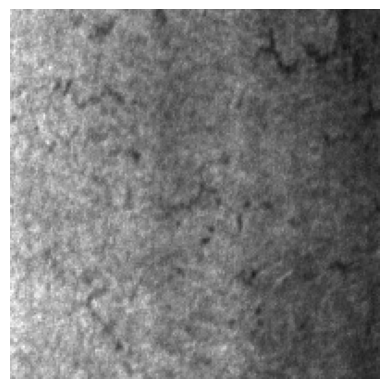

In [ ]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
import os
import cv2

train_path = "/content/NEU-DET/NEU-DET/train/images"

images = []
labels = []

for label in os.listdir(train_path):

    class_path = os.path.join(train_path, label)

    if os.path.isdir(class_path):

        for filename in os.listdir(class_path):

            img_path = os.path.join(class_path, filename)

            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)
                labels.append(label)

In [ ]:
print("Total images:", len(images))
print("First label:", labels[0])
print("Image shape:", images[0].shape)

Total images: 1440
First label: patches
Image shape: (200, 200, 3)


In [ ]:
from collections import Counter

print(Counter(labels))

Counter({'patches': 240, 'scratches': 240, 'crazing': 240, 'inclusion': 240, 'pitted_surface': 240, 'rolled-in_scale': 240})


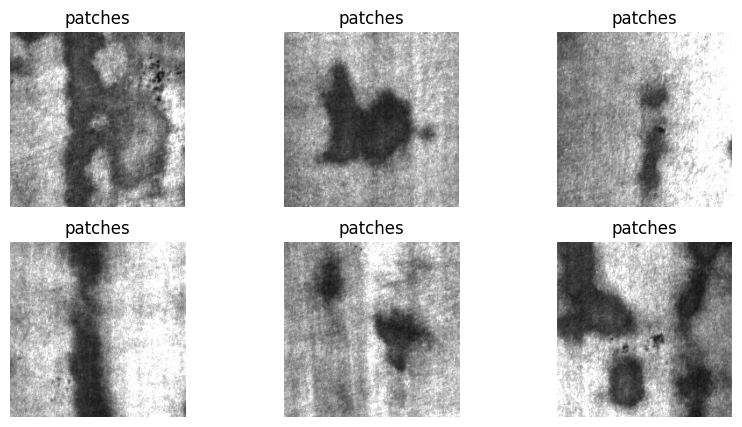

In [ ]:
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)

    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))

    plt.title(labels[i])

    plt.axis("off")

plt.show()

In [ ]:
resized_image = cv2.resize(images[0], (224,224))

print("Original Shape :", images[0].shape)
print("Resized Shape  :", resized_image.shape)

Original Shape : (200, 200, 3)
Resized Shape  : (224, 224, 3)


In [ ]:
resized_images = []

for img in images:

    resized_img = cv2.resize(img, (224,224))

    resized_images.append(resized_img)

In [ ]:
print("Original:", images[0].shape)
print("Resized :", resized_images[0].shape)
print("Total resized images:", len(resized_images))

Original: (200, 200, 3)
Resized : (224, 224, 3)
Total resized images: 1440


In [ ]:
normalized_images = []

for img in resized_images:

    normalized_img = img / 255.0

    normalized_images.append(normalized_img)

In [ ]:
print("Before normalization")
print("Minimum:", resized_images[0].min())
print("Maximum:", resized_images[0].max())

print()

print("After normalization")
print("Minimum:", normalized_images[0].min())
print("Maximum:", normalized_images[0].max())

Before normalization
Minimum: 11
Maximum: 255

After normalization
Minimum: 0.043137254901960784
Maximum: 1.0


In [ ]:
blurred_images = []

for img in normalized_images:

    blurred_img = cv2.GaussianBlur(img, (5,5), 0)

    blurred_images.append(blurred_img)

In [ ]:
print("Normalized Image Shape :", normalized_images[0].shape)
print("Blurred Image Shape    :", blurred_images[0].shape)
print("Total Blurred Images   :", len(blurred_images))

Normalized Image Shape : (224, 224, 3)
Blurred Image Shape    : (224, 224, 3)
Total Blurred Images   : 1440


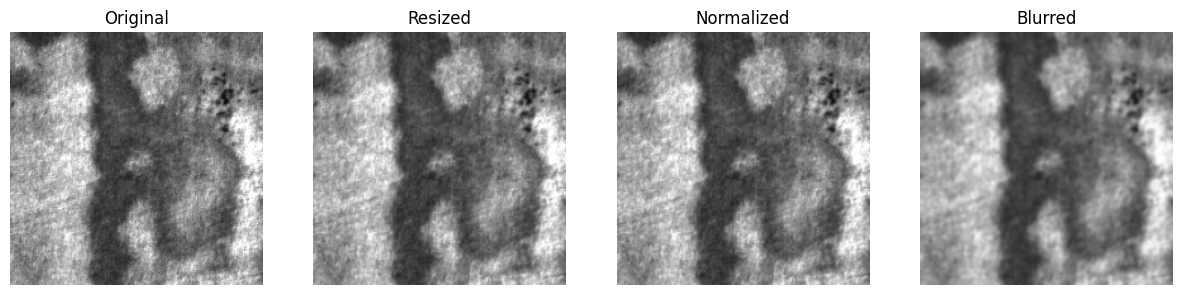

In [ ]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(15,5))

# ---------------- Original ----------------
plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

# ---------------- Resized ----------------
plt.subplot(1,4,2)
plt.imshow(cv2.cvtColor(resized_images[0], cv2.COLOR_BGR2RGB))
plt.title("Resized")
plt.axis("off")

# ---------------- Normalized ----------------
plt.subplot(1,4,3)
plt.imshow(normalized_images[0])
plt.title("Normalized")
plt.axis("off")

# ---------------- Blurred ----------------
plt.subplot(1,4,4)
plt.imshow(blurred_images[0])
plt.title("Blurred")
plt.axis("off")

plt.show()